In [7]:
import plotly.express as px
import pandas as pd
from collections import Counter
import re
from wordcloud import WordCloud, STOPWORDS

import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('preprocessed_award_data.csv')

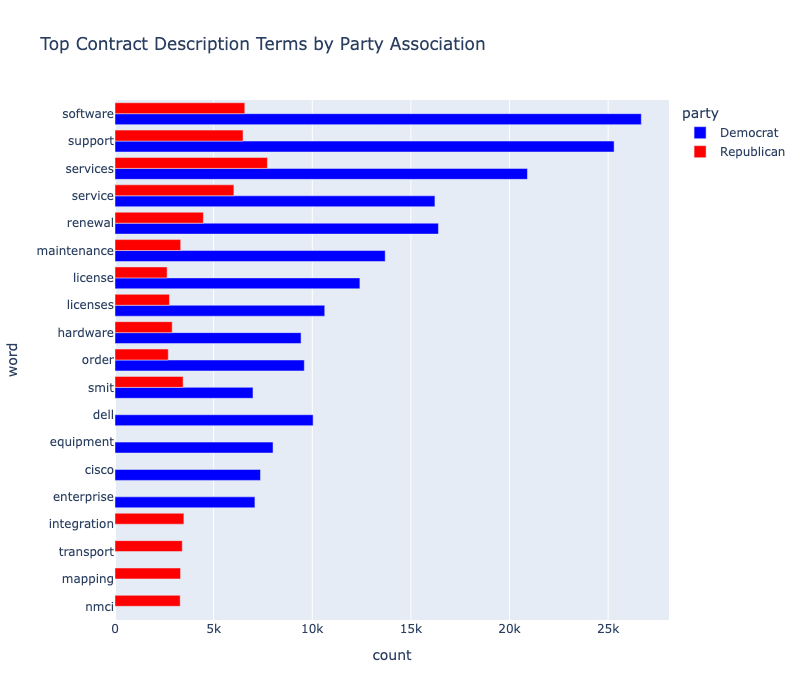

In [4]:
def get_freq_df(dataframe, party_val, party_name):
    # 1. Filter by party
    subset = dataframe[dataframe['is_democrat'] == party_val]
    
    # 2. Convert to string and handle NaNs to avoid the TypeError
    # We use .astype(str) to ensure numbers/NaNs don't break the join
    text_series = subset['Description'].fillna('').astype(str).str.lower()
    
    # 3. Join into one giant string
    text = " ".join(text_series)
    
    # 4. Find words and filter
    words = re.findall(r'\b\w{4,}\b', text)
    stops = {'with', 'from', 'this', 'that', 'government', 'contract', 'award'}
    counts = Counter([w for w in words if w not in stops]).most_common(15)
    
    return pd.DataFrame(counts, columns=['word', 'count']).assign(party=party_name)

# Generate data for both groups
dem_df = get_freq_df(df, 1, 'Democrat')
rep_df = get_freq_df(df, 0, 'Republican')
viz_df = pd.concat([dem_df, rep_df])

# Create the visual
fig = px.bar(viz_df, x='count', y='word', color='party', barmode='group',
             title='Top Contract Description Terms by Party Association',
             color_discrete_map={'Democrat': 'blue', 'Republican': 'red'},
             orientation='h', height=700)

fig.update_layout(yaxis={'categoryorder':'total ascending'})
fig.show()

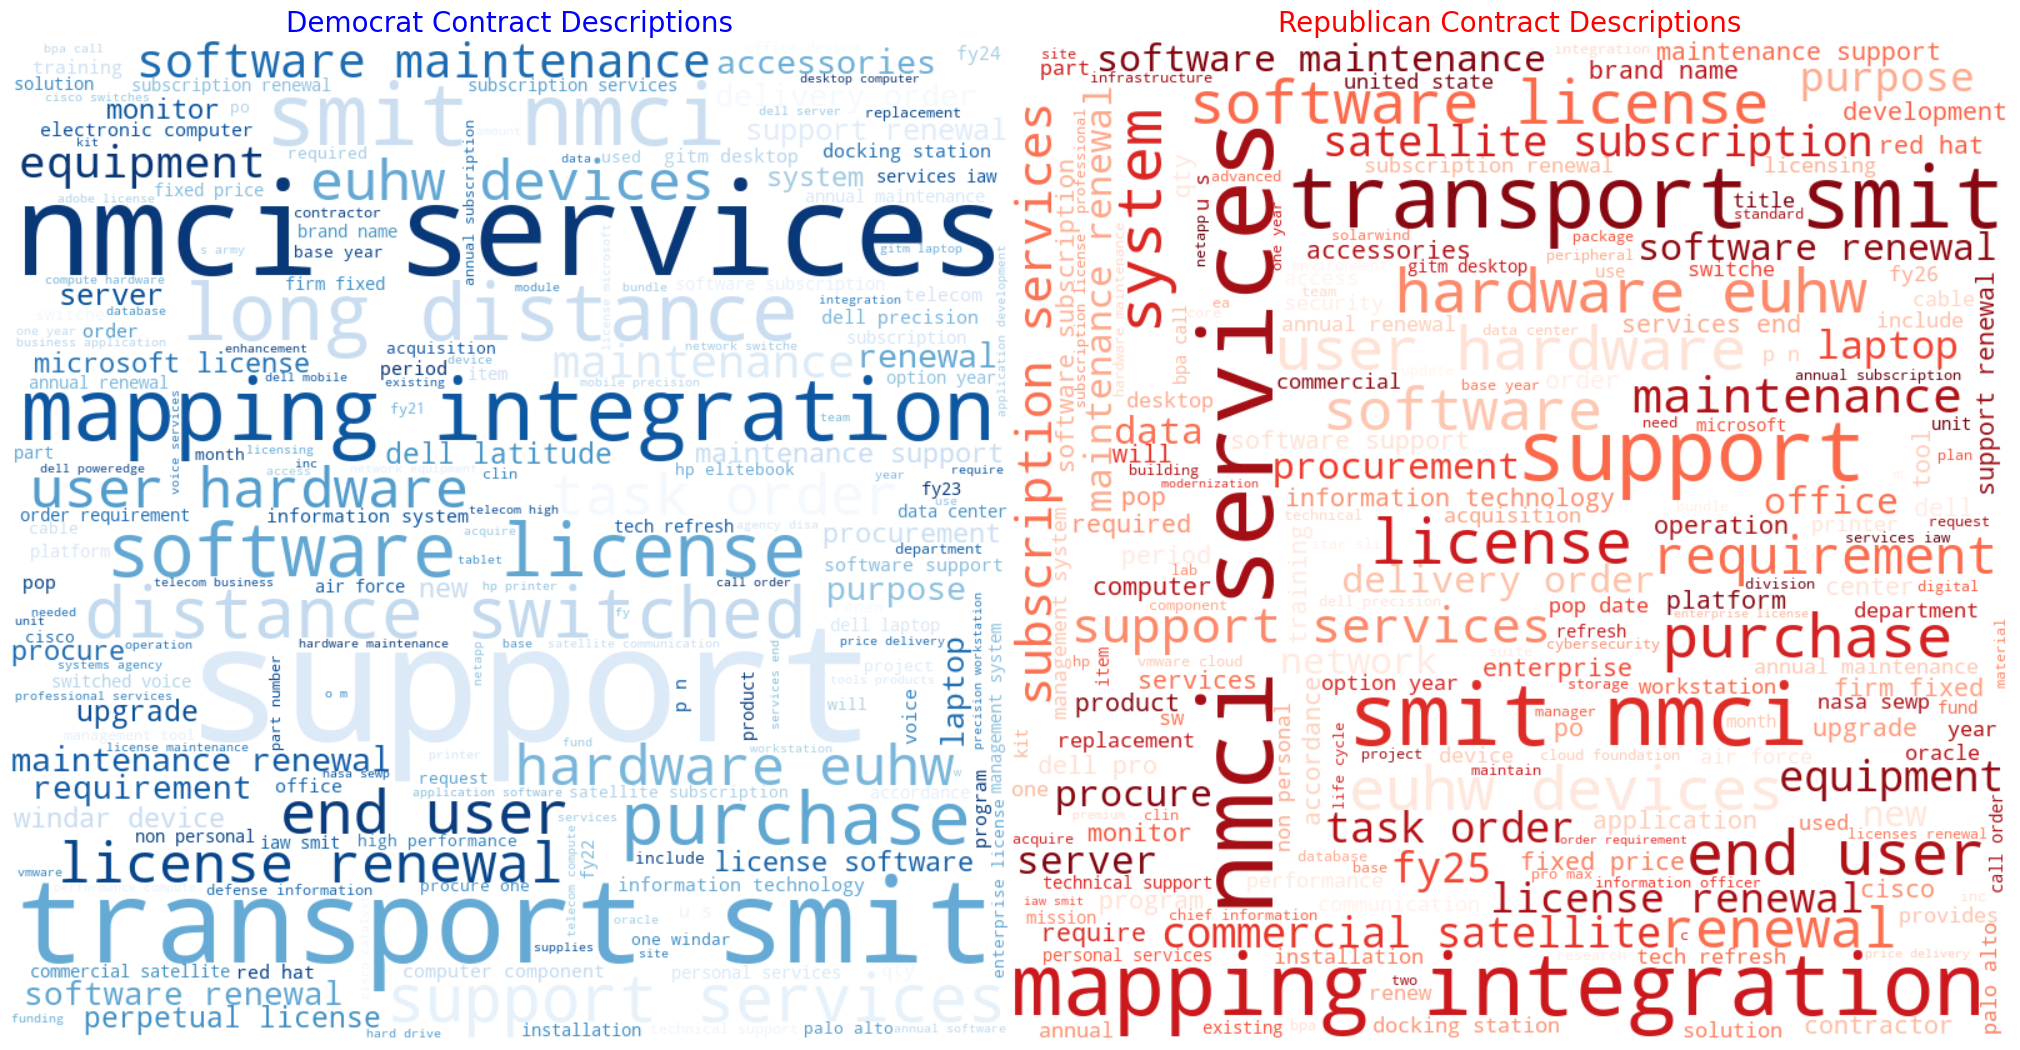

In [8]:
# Update stop words to remove generic contract terms
custom_stopwords = set(STOPWORDS)
custom_stopwords.update(['government', 'contract', 'award', 'description', 'service', 'provision', 'provide'])

# Extract and clean Democrat text / NaNs
dem_text = " ".join(df[df['is_democrat'] == 1]['Description'].fillna('').astype(str).str.lower())

# Extract and clean Republican text / NaNs
rep_text = " ".join(df[df['is_democrat'] == 0]['Description'].fillna('').astype(str).str.lower())

# Plotting Area (1 row, 2 columns)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

# Democrat Cloud
if dem_text.strip(): # Check if text exists
    dem_cloud = WordCloud(width=800, height=800, 
                          background_color='white',
                          colormap='Blues', # Blue color scheme
                          stopwords=custom_stopwords,
                          min_font_size=10).generate(dem_text)
    ax1.imshow(dem_cloud, interpolation='bilinear')
    ax1.set_title('Democrat Contract Descriptions', fontsize=20, color='blue')
else:
    ax1.text(0.5, 0.5, 'No Democrat Data', horizontalalignment='center')
ax1.axis("off")

# Republican Cloud
if rep_text.strip(): # Check if text exists
    rep_cloud = WordCloud(width=800, height=800, 
                          background_color='white',
                          colormap='Reds', # Red color scheme
                          stopwords=custom_stopwords,
                          min_font_size=10).generate(rep_text)
    ax2.imshow(rep_cloud, interpolation='bilinear')
    ax2.set_title('Republican Contract Descriptions', fontsize=20, color='red')
else:
    ax2.text(0.5, 0.5, 'No Republican Data', horizontalalignment='center')
ax2.axis("off")

# Display
plt.tight_layout(pad=0)
plt.show()